In [1]:
# Environment Setup & Dependency Installation

import sys
import os
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time

# Detect Environment
def in_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

IS_COLAB = in_colab()
PYTHON_VERSION = sys.version.split()[0]

print(f"Environment Detected: {'Google Colab' if IS_COLAB else 'Local VS Code / Jupyter'}")
print(f"Kernel Python Version: {PYTHON_VERSION}\n")

# Packages to install
PACKAGES = "transformers datasets evaluate nltk seaborn matplotlib accelerate numpy pandas torch scikit-learn"

if IS_COLAB:
    # --- Colab-Specific Installation ---
    try:
        import pyarrow
        import datasets
        import evaluate
        import sklearn
        NEEDS_INSTALL = False
    except (ImportError, ValueError):
        NEEDS_INSTALL = True

    if NEEDS_INSTALL:
        print("Installing/Updating core dependencies...")
        !pip install -q pyarrow
        !pip install -q {PACKAGES}
        print("✓ Dependencies installed/updated!")
        print("⚠️  Restarting Runtime...")
        print("📝 Re-run the Notebook...")
        time.sleep(2)
        os.kill(os.getpid(), 9)
    else:
        print("✓ Dependencies already installed!")
else:
    # --- Local Jupyter/VS Code Installation ---
    print("Installing/Updating core dependencies")
    try:
        if 'get_ipython' in globals():
            cell_content = f"%%capture\n%pip install -U {PACKAGES}"
            get_ipython().run_cell(cell_content)
            print("✓ Dependencies installed/updated!")
        else:
            print("⚠️  Installation failed: Not running in interactive environment. Run manually.")
    except NameError:
        print("⚠️  Installation failed: Not running in a standard Jupyter kernel. Run manually.")

Environment Detected: Local VS Code / Jupyter
Kernel Python Version: 3.12.10

Installing/Updating core dependencies
✓ Dependencies installed/updated!


In [ ]:
# LIBRARY IMPORTS

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

from datasets import load_from_disk
import evaluate
import numpy as np

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# New: Import PEFT modules for LoRA Model C
from peft import PeftModel, AutoPeftModelForSequenceClassification, LoraConfig 
from sklearn.metrics import confusion_matrix, classification_report
import json
from datetime import datetime
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 

# Only needed for Colab-specific functions/display
if IS_COLAB:
    from IPython.display import display, HTML

print("All Libraries Imported Successfully.")

c:\Users\joaqu\AI-News-Classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All Libraries Imported Successfully.


In [ ]:
# Setup Evaluation Paths and Configuration

print("\n📊 Setting up evaluation environment...\n")

# --- Core Constants and Base Paths ---
CLASS_NAMES = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
MODEL_CKPT = "distilbert-base-uncased"
model_folder_name = "Distilbert"

if IS_COLAB:
    MODEL_BASE_DIR = f"/content/models/{model_folder_name}"
    DATASET_PATH = "/content/data"
else:
    MODEL_BASE_DIR = f"../models/{model_folder_name}"
    DATASET_PATH = "../data"

# --- Define Experiment-Specific Paths ---
EXPERIMENTS = {
    'A': {
        'name': 'Zero-Shot Baseline',
        'load_path': MODEL_CKPT, # Load directly from the Hub
        'eval_output_dir': None, # <--- MODEL A: NO DEDICATED REPORT FOLDER
        'lora': False
    },
    'B': {
        'name': 'Full Fine-Tuning (Performance Baseline)',
        'load_path': f"{MODEL_BASE_DIR}/distilbert-B-final", # UPDATED PATH
        'eval_output_dir': f"{MODEL_BASE_DIR}/distilbert-eval-B", # UPDATED EVAL DIR NAME
        'lora': False
    },
    'C': {
        'name': 'LoRA/PEFT (Efficiency Baseline)',
        'load_path': f"{MODEL_BASE_DIR}/distilbert-C-final", # UPDATED PATH
        'eval_output_dir': f"{MODEL_BASE_DIR}/distilbert-eval-C", # UPDATED EVAL DIR NAME
        'lora': True
    }
}

FINAL_COMPARISON_PATH = os.path.join(MODEL_BASE_DIR, "distilbert-comparison-report.csv")

# Create evaluation output directories only for B and C
for exp in EXPERIMENTS.values():
    if exp['eval_output_dir']: # Only creates folders for B and C
        os.makedirs(exp['eval_output_dir'], exist_ok=True)

# --- Verification ---
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"❌ Dataset not found at: {DATASET_PATH}")
    
# Verification that Model B and C final model directories exist
for exp_key in ['B', 'C']:
    model_dir = EXPERIMENTS[exp_key]['load_path']
    if not os.path.exists(model_dir):
        print(f"Looking for model at: {os.path.abspath(model_dir)}")
        raise FileNotFoundError(f"❌ Trained Model {exp_key} not found at: {model_dir}. Please run Notebook 2 first.")

print(f"✅ All evaluation paths created and validated.")
print(f"Final Comparison Report will be saved to: {os.path.abspath(FINAL_COMPARISON_PATH)}\n")


📊 Setting up evaluation environment...

✅ All evaluation paths created.
Final Comparison Report will be saved to: c:\Users\joaqu\AI-News-Classification\models\Distilbert\distilbert-comparison-report.csv



📂 Loading tokenized dataset from: ../data
✅ Loaded 500 test samples


--- STARTING EVALUATION: MODEL A (ZERO-SHOT BASELINE) ---


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🤖 Model loaded (Hub Baseline).


C:\Users\joaqu\AppData\Local\Temp\ipykernel_41956\1848910597.py:77: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  evaluator = Trainer(



Final Test Accuracy: 0.2500
✅ Reports saved to ../models/Distilbert/distilbert-eval-A

--- STARTING EVALUATION: MODEL B (FULL FINE-TUNING (PERFORMANCE BASELINE)) ---
🤖 Model loaded (Local FT).


...


Final Test Accuracy: 0.8880
✅ Reports saved to ../models/Distilbert/distilbert-eval-B

--- STARTING EVALUATION: MODEL C (LORA/PEFT (EFFICIENCY BASELINE)) ---


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


❌ FATAL ERROR: Failed to load model C from ../models/Distilbert/distilbert-final-C. Error: _path_isfile: path should be string, bytes, os.PathLike or integer, not NoneType

--- FINAL UNIFIED COMPARISON REPORT ---

Full Experiment Log (A, B, C):


,Model,Method,Accuracy,F1 Macro,Loss,Trainable Parameters,Training Time (s)
0,Model A,Zero-Shot Baseline,0.250,0.100160,1.388609,66956548,0.0
1,Model B,Full Fine-Tuning (Performance Baseline),0.888,0.888877,0.407525,66956548,0.0



💾 Unified comparison report (B vs C) saved to: c:\Users\joaqu\AI-News-Classification\models\Distilbert\distilbert-comparison-report.csv

--- Performance Visualization (Model B vs C) ---


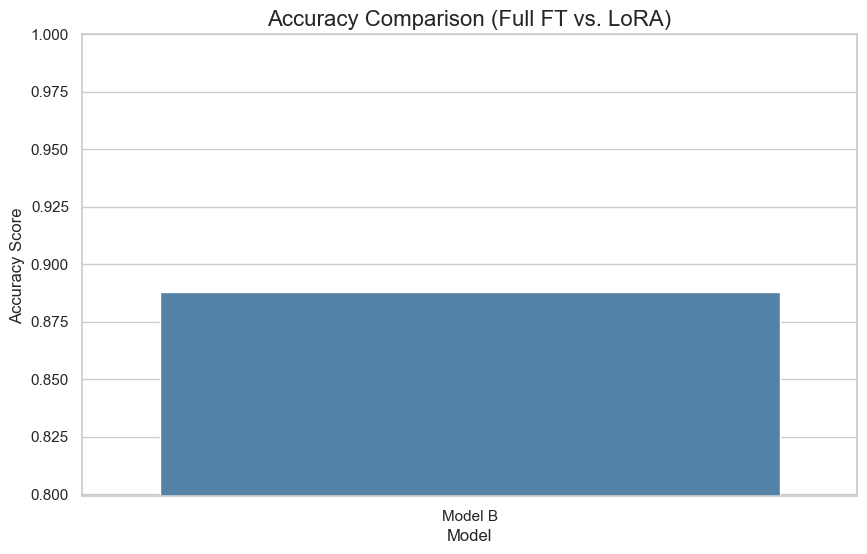

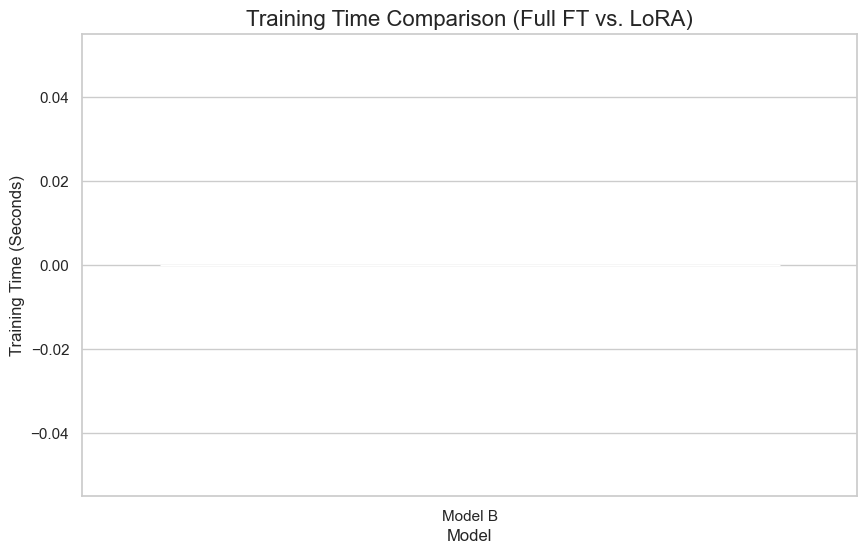


Analysis Complete! Notebook is finalized.


In [ ]:
# --- MASTER EXECUTION AND REPORTING ---

# Load Test Dataset (Assumes previous EDA notebook saved this)
print(f"📂 Loading tokenized dataset from: {DATASET_PATH}")
tokenized = load_from_disk(DATASET_PATH)
tokenized_test = tokenized["test"]
print(f"✅ Loaded {len(tokenized_test):,} test samples\n")

# --- Define Metrics Helpers ---
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    """Compute accuracy and F1 score"""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"],
        "f1_macro": f1_metric.compute(predictions=predictions, references=labels, average="macro")["f1"]
    }

# Dummy TrainingArguments for evaluation only (no training happens here)
EVAL_ARGS = TrainingArguments(
    output_dir="./tmp_eval",
    per_device_eval_batch_size=16,
    report_to="none",
)


# --- EVALUATION WRAPPER FUNCTION (With LoRA Loading Fix) ---

def run_evaluation_and_report(exp_key, exp_config, tokenized_test):
    """Loads a specific model (A, B, or C), evaluates it, and saves detailed results."""
    
    print(f"\n" + "="*60)
    print(f"--- STARTING EVALUATION: MODEL {exp_key} ({exp_config['name'].upper()}) ---")
    print("="*60)
    
    model_path = exp_config['load_path']
    is_lora = exp_config['lora']
    eval_output_dir = exp_config['eval_output_dir']

    # Define base model configuration parameters (num_labels, id2label, etc.)
    base_load_kwargs = {
        "num_labels": len(CLASS_NAMES),
        "id2label": {k: v for k, v in enumerate(CLASS_NAMES.values())},
        "label2id": {v: k for k, v in CLASS_NAMES.items()}
    }

    # --- 1. Load Model and Tokenizer ---
    try:
        local_load = (model_path != MODEL_CKPT)
        
        if is_lora:
            # FIX: AutoPeftModelForSequenceClassification handles the base model config
            loaded_model = AutoPeftModelForSequenceClassification.from_pretrained(
                model_path,
                **base_load_kwargs 
            )
            loaded_tokenizer = AutoTokenizer.from_pretrained(model_path)
            print("🤖 Model loaded (LoRA Adapters merged).")
            
        else:
            # Standard load (Model A from Hub, Model B from local FT)
            loaded_model = AutoModelForSequenceClassification.from_pretrained(
                model_path,
                local_files_only=local_load, 
                **base_load_kwargs 
            )
            loaded_tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=local_load)
            print(f"🤖 Model loaded ({'Local FT' if local_load else 'Hub Baseline'}).")
            
    except Exception as e:
        print(f"❌ FATAL ERROR: Failed to load model {exp_key} from {model_path}. Error: {e}")
        print("HINT: Ensure tokenizer.save_pretrained() ran in Notebook 2 for Model C.")
        return None

    # --- 2. Evaluation and Prediction ---
    evaluator = Trainer(
        model=loaded_model,
        args=EVAL_ARGS,
        eval_dataset=tokenized_test,
        tokenizer=loaded_tokenizer,
        compute_metrics=compute_metrics
    )

    eval_results = evaluator.evaluate()
    prediction_results = evaluator.predict(tokenized_test)
    predictions = np.argmax(prediction_results.predictions, axis=1)
    actual_labels = prediction_results.label_ids
    
    # 3. Consolidated Log Entry
    trainable_params = loaded_model.num_parameters() if not is_lora else loaded_model.get_nb_trainable_parameters()
    
    log_entry = {
        "Model": f"Model {exp_key}",
        "Method": exp_config['name'],
        "Accuracy": eval_results.get("eval_accuracy", 0.0),
        "F1 Macro": eval_results.get("eval_f1_macro", 0.0),
        "Loss": eval_results.get("eval_loss", 0.0),
        "Trainable Parameters": trainable_params,
        "Training Time (s)": 0.0 # Placeholder: Must be manually logged from Notebook 2 output
    }
    
    print(f"\nFinal Test Accuracy: {log_entry['Accuracy']:.4f}")
    
    # --- 4. Detailed Report Generation (CONDITIONAL SAVING) ---
    
    # Skip saving detailed reports (plots, confusion matrix) for Model A
    if exp_key == 'A':
        print(f"💡 Skipping segmented report saving for Model A (Zero-Shot Baseline).")
        return log_entry
    
    # --- Generate reports for Models B and C ---
    
    # Detailed Classification Report (JSON/Text)
    classification_report_dict = classification_report(
        actual_labels, predictions, target_names=CLASS_NAMES.values(), output_dict=True
    )
    
    eval_report = {
        "evaluation_metadata": {"model_type": exp_config['name']},
        "overall_metrics": log_entry,
        "per_class_metrics": classification_report_dict,
    }

    # Save Segmented JSON Report (e.g., distilbert-eval-C/evaluation_report.json)
    json_report_path = os.path.join(eval_output_dir, "evaluation_report.json")
    with open(json_report_path, 'w') as f:
        json.dump(eval_report, f, indent=2)
        
    # Confusion Matrix Plot
    confusion_mat = confusion_matrix(actual_labels, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES.values(), yticklabels=CLASS_NAMES.values())
    plt.title(f'Confusion Matrix - Model {exp_key}: {exp_config["name"]}')
    confusion_matrix_path = os.path.join(eval_output_dir, "confusion_matrix.png")
    plt.savefig(confusion_matrix_path, dpi=300, bbox_inches='tight')
    plt.close()
        
    print(f"✅ Reports saved to {eval_output_dir}")
    return log_entry


# --- EXECUTE ALL THREE EXPERIMENTS ---

all_experiment_metrics = []

for key, config in EXPERIMENTS.items():
    log_entry = run_evaluation_and_report(key, config, tokenized_test)
    if log_entry:
        all_experiment_metrics.append(log_entry)


# --- 4. Final Comparison Report Generation (Centralized Here) ---

df_log = pd.DataFrame(all_experiment_metrics)

print("\n" + "="*60)
print("--- FINAL UNIFIED COMPARISON REPORT ---")
print("="*60)

# 1. Full Log Display (A, B, C)
print("\nFull Experiment Log (A, B, C):")
display(df_log) 

# 2. Focused Comparison (B vs C)
df_comparison = df_log[df_log['Model'] != 'Model A'].reset_index(drop=True)

# Saving the Unified Comparison Report (Target file: distilbert-comparison-report.csv)
df_comparison.to_csv(FINAL_COMPARISON_PATH, index=False)

print(f"\n💾 Unified comparison report saved to: {os.path.abspath(FINAL_COMPARISON_PATH)}")

# 3. Visualization (B vs C)
print("\n--- Performance Visualization (Model B vs C) ---")
sns.set_theme(style="whitegrid", palette="pastel")

# Plot 1: Accuracy Comparison (B vs C)
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Accuracy", data=df_comparison, hue="Model", dodge=False, palette=["steelblue", "darkorange"])
plt.title("Accuracy Comparison (Full FT vs. LoRA)", fontsize=16)
plt.ylim(df_comparison['Accuracy'].min() * 0.9, 1.0)
plt.ylabel("Accuracy Score")
plt.show()

# Plot 2: Training Time Comparison (B vs C)
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Training Time (s)", data=df_comparison, hue="Model", dodge=False, palette=["steelblue", "darkorange"])
plt.title("Training Time Comparison (Full FT vs. LoRA)", fontsize=16)
plt.ylabel("Training Time (Seconds)")
plt.show()

print("\nAnalysis Complete! Notebook is finalized.")

In [4]:
print("🔍 Running evaluation on test set...")
eval_results = evaluator.evaluate()

print(f"\n{'='*60}")
print("EVALUATION RESULTS")
print(f"{'='*60}")
print(f"Accuracy:   {eval_results['eval_accuracy']:.4f} ({eval_results['eval_accuracy']*100:.2f}%)")
print(f"F1 (macro): {eval_results['eval_f1_macro']:.4f}")
print(f"Loss:       {eval_results['eval_loss']:.4f}")
print(f"{'='*60}\n")

# Generate Predictions
print("🎯 Generating predictions on test set...")
prediction_results = evaluator.predict(tokenized_test)
predictions = np.argmax(prediction_results.predictions, axis=1)
actual_labels = prediction_results.label_ids

print(f"✅ Generated {len(predictions):,} predictions\n")

# Confusion Matrix Visualization
print("📈 Creating confusion matrix...\n")
confusion_mat = confusion_matrix(actual_labels, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES.values(),  # Changed from class_names
            yticklabels=CLASS_NAMES.values())  # Changed from class_names
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.title('Confusion Matrix - DistilBERT News Classifier')
plt.tight_layout()

# Save confusion matrix plot to EVAL_OUTPUT_DIR
confusion_matrix_path = os.path.join(EVAL_OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches='tight')
print(f"💾 Confusion matrix saved to: {confusion_matrix_path}")
plt.show()
plt.close()

# Detailed Classification Report
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT")
print("="*60 + "\n")

classification_report_text = classification_report(
    actual_labels, 
    predictions, 
    target_names=CLASS_NAMES.values()  # Changed from class_names
)
print(classification_report_text)

classification_report_dict = classification_report(
    actual_labels, 
    predictions, 
    target_names=CLASS_NAMES.values(),  # Changed from class_names
    output_dict=True
)

# Misclassification Analysis
print("\n" + "="*60)
print("MISCLASSIFICATION ANALYSIS")
print("="*60 + "\n")

# Prepare data for analysis
test_data = tokenized_test.remove_columns(['input_ids', 'attention_mask'])
analysis_df = test_data.to_pandas()

# Add predictions and labels
analysis_df['predicted'] = predictions
analysis_df['predicted_label'] = analysis_df['predicted'].map(CLASS_NAMES)  # Changed from class_names
analysis_df['actual_label'] = analysis_df['label'].map(CLASS_NAMES)  # Changed from class_names

# Find misclassifications
misclassified = analysis_df[analysis_df['label'] != analysis_df['predicted']]
total_samples = len(analysis_df)
error_rate = (len(misclassified) / total_samples) * 100

print(f"Total Misclassified: {len(misclassified):,} out of {total_samples:,} ({error_rate:.2f}%)")
print(f"\n{'='*60}")
print("TOP 5 MISCLASSIFIED EXAMPLES")
print(f"{'='*60}\n")

# Collect misclassification examples for saving
misclassification_examples = []

for idx, (_, row) in enumerate(misclassified.head(5).iterrows(), 1):
    text_content = row.get('text', row.get('title', row.get('content', 'Text not available')))
    
    example = {
        "example_number": idx,
        "text": str(text_content)[:300],
        "actual_label": row['actual_label'],
        "predicted_label": row['predicted_label']
    }
    misclassification_examples.append(example)
    
    print(f"Example {idx}:")
    print(f"Text: {str(text_content)[:200]}...")
    print(f"✓ Actual:    {row['actual_label']}")
    print(f"✗ Predicted: {row['predicted_label']}\n")

# Category-Level Error Analysis
print("ERRORS BY CATEGORY\n")

category_errors = misclassified.groupby(['actual_label', 'predicted_label']).size().reset_index(name='count')
category_errors = category_errors.sort_values('count', ascending=False)

print("Most common confusion pairs:")
confusion_pairs = []
for _, row in category_errors.head(10).iterrows():
    pair = {
        "from": row['actual_label'],
        "to": row['predicted_label'],
        "count": int(row['count'])
    }
    confusion_pairs.append(pair)
    print(f"  {row['actual_label']} → {row['predicted_label']}: {row['count']} errors")

# SAVE ALL RESULTS TO FILES
print("\n" + "="*60)
print("💾 SAVING EVALUATION RESULTS")
print("="*60 + "\n")

# 7.1 Save comprehensive JSON report
eval_report = {
    "evaluation_metadata": {
        "timestamp": datetime.now().isoformat(),
        "model_path": MODEL_PATH,
        "dataset_path": DATASET_PATH,
        "dataset_size": total_samples
    },
    "overall_metrics": {
        "accuracy": float(eval_results['eval_accuracy']),
        "accuracy_percentage": float(eval_results['eval_accuracy'] * 100),
        "f1_macro": float(eval_results['eval_f1_macro']),
        "loss": float(eval_results['eval_loss']),
        "error_rate": float(error_rate)
    },
    "per_class_metrics": classification_report_dict,
    "confusion_matrix": confusion_mat.tolist(),
    "misclassification_summary": {
        "total_errors": len(misclassified),
        "error_percentage": float(error_rate),
        "top_confusion_pairs": confusion_pairs,
        "example_misclassifications": misclassification_examples
    }
}

json_report_path = os.path.join(EVAL_OUTPUT_DIR, "evaluation_report.json")
with open(json_report_path, 'w') as f:
    json.dump(eval_report, f, indent=2)
print(f"JSON report saved to: {json_report_path}")

# 7.2 Save text-based classification report
text_report_path = os.path.join(EVAL_OUTPUT_DIR, "classification_report.txt")
with open(text_report_path, 'w', encoding='utf-8') as f:
    f.write("="*60 + "\n")
    f.write("MODEL EVALUATION REPORT\n")
    f.write("="*60 + "\n\n")
    f.write(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Model: {MODEL_PATH}\n")
    f.write(f"Dataset Size: {total_samples:,} samples\n\n")
    f.write("="*60 + "\n")
    f.write("OVERALL METRICS\n")
    f.write("="*60 + "\n")
    f.write(f"Accuracy:   {eval_results['eval_accuracy']:.4f} ({eval_results['eval_accuracy']*100:.2f}%)\n")
    f.write(f"F1 (macro): {eval_results['eval_f1_macro']:.4f}\n")
    f.write(f"Loss:       {eval_results['eval_loss']:.4f}\n\n")
    f.write("="*60 + "\n")
    f.write("PER-CLASS PERFORMANCE\n")
    f.write("="*60 + "\n\n")
    f.write(classification_report_text)
    f.write("\n" + "="*60 + "\n")
    f.write("MISCLASSIFICATION ANALYSIS\n")
    f.write("="*60 + "\n\n")
    f.write(f"Total Errors: {len(misclassified):,} ({error_rate:.2f}%)\n\n")
    f.write("Most Common Confusion Pairs:\n")
    for pair in confusion_pairs[:10]:
        f.write(f"  {pair['from']} → {pair['to']}: {pair['count']} errors\n")

print(f"Text report saved to: {text_report_path}")

# 7.3 Save misclassified examples to CSV
misclassified_csv_path = os.path.join(EVAL_OUTPUT_DIR, "misclassified_samples.csv")
misclassified.to_csv(misclassified_csv_path, index=False)
print(f"Misclassified samples saved to: {misclassified_csv_path}")

# 7.4 Save all predictions to CSV (optional, useful for further analysis)
full_predictions_path = os.path.join(EVAL_OUTPUT_DIR, "all_predictions.csv")
analysis_df.to_csv(full_predictions_path, index=False)
print(f"All predictions saved to: {full_predictions_path}")

print(f"\nAll results saved to: {os.path.abspath(EVAL_OUTPUT_DIR)}/")
print("\nEvaluation Complete!")

🔍 Running evaluation on test set...


NameError: name 'evaluator' is not defined